# Animations

In [2]:
import numpy as np
import os
os.environ['pRT_input_data_path'] = "/media/natalie/Data1/input_data_std/input_data"
import imageio.v2
import glob
from pRT_model import pRT_spectrum
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pathlib
import pandas as pd
from petitRADTRANS import Radtrans
from utils import *
from config_run import init_retrieval

retrieval=init_retrieval(target='2M0355',PT_type='PTgrad',chem='freechem',Nlive=400,evtol=0.5)
path=pathlib.Path('/home/natalie/Desktop/atm_retrieval/2M0355/freechem_PTgrad_N400_ev0.5/params_dict.pickle')
final_params=load_pickle(path)

In [3]:
# make continuous atmosphere objects file to avoid gaps from CRIRES+
def get_atmosphere_objects(retrieval):

    file=pathlib.Path(f'atmosphere_objects_continuous.pickle')
    if file.exists():
        atmosphere_object= load_pickle(file)
        return atmosphere_object
    else:
        wl_pad=7 # wavelength padding because spectrum is not wavelength shifted yet
        wlmin=np.min(retrieval.K2166)-wl_pad
        wlmax=np.max(retrieval.K2166)+wl_pad
        wlen_range=np.array([wlmin,wlmax])*1e-3 # nm to microns

        atmosphere_object = Radtrans(line_species=retrieval.species_pRT,
                            rayleigh_species = ['H2', 'He'],
                            continuum_opacities = ['H2-H2', 'H2-He'],
                            wlen_bords_micron=wlen_range, 
                            mode='lbl',
                            lbl_opacity_sampling=10) # 10 sufficient for plots
        atmosphere_object.setup_opa_structure(retrieval.pressure)
    save_pickle(atmosphere_object,file)
    return atmosphere_object

atmosphere_objects_continuous = get_atmosphere_objects(retrieval)

In [16]:
# manually set values for some params for better visualisation of varying params
param_dict=final_params.copy()
species_info = pd.read_csv(os.path.join('species_info.csv'),index_col=0)
log_species=[]
for species in retrieval.species_names:
    logspec=f"log_{species}"
    log_species.append(logspec)

def save_gif(filename, folder, repeat_first_frame=0, repeat_final_frame=0, 
             loopback=False,fps=10,delete_imgs=True):
    with imageio.get_writer(filename, mode='I',fps=fps) as writer:
        filenames = glob.glob(os.path.join(folder, '*.jpg'))
        filenames = list(sorted(filenames))
        for i in range(repeat_first_frame):
            image = imageio.v2.imread(filenames[0])
            writer.append_data(image)
        for filename in filenames:
            image = imageio.v2.imread(filename)
            writer.append_data(image)
        for i in range(repeat_final_frame):
            image = imageio.v2.imread(filenames[-1])
            writer.append_data(image)
        if loopback:
            for filename in filenames[:-1][::-1]:
                image = imageio.v2.imread(filename)
                writer.append_data(image)

    if delete_imgs==True:
        os.system(f"rm -rf {folder}")

def convolve_to_resolution(in_wlen, in_flux, out_res, in_res=None):
    from astropy import units as u
    from scipy.ndimage import gaussian_filter
    
    if isinstance(in_wlen, u.Quantity):
        in_wlen = in_wlen.to(u.nm).value
    if in_res is None:
        in_res = np.mean((in_wlen[:-1]/np.diff(in_wlen)))
    # delta lambda of resolution element is FWHM of the LSF's standard deviation:
    sigma_LSF = np.sqrt(1./out_res**2-1./in_res**2)/(2.*np.sqrt(2.*np.log(2.)))
    spacing = np.mean(2.*np.diff(in_wlen)/(in_wlen[1:]+in_wlen[:-1]))

    # Calculate the sigma to be used in the gauss filter in pixels
    sigma_LSF_gauss_filter = sigma_LSF/spacing
    out_flux = np.tile(np.nan, in_flux.shape)
    nans = np.isnan(in_flux)
    out_flux[~nans] = gaussian_filter(in_flux[~nans], sigma = sigma_LSF_gauss_filter, mode = 'reflect')

    return out_flux

def make_animation(param,p_range,param_dictionary=final_params,retr_obj=retrieval,
                   isoCO=False, isoH2O=False, num=20,label=None,name=None):

    name=param if name==None else name
    label=param if label==None else label
    param_dict=param_dictionary.copy()

    folder=f'./animation/{name}'
    os.makedirs(f"{folder}", exist_ok=True)
    gifname=f'./animation/{name}.gif'
    if isoCO==True or isoH2O==True:
        gifname=f'./animation/{name}_iso.gif'

    retr_obj.data_wave
    wl=np.linspace(np.min(retr_obj.data_wave),np.max(retr_obj.data_wave),int(1e4))
    Kband=retr_obj.target.K2166

    # remove other species to highlight effects of selected species
    if param in log_species:
        for logspecies in log_species:
            param_dict[logspecies]=-12

    # crank up cloud parameters to make effects visible
    if 'gray' in param:
        param_dict['log_opa_base_gray']=0
        param_dict['log_P_base_gray']=0
        param_dict['fsed_gray']=5
    retr_obj.parameters.params=param_dict

    fig,(var,ax) =plt.subplots(1,2,figsize=(6,3),dpi=150,gridspec_kw={'width_ratios': [1,35]})
    #ax.set_ylabel('Flux')
    ax.set_xlabel('Wavelength [nm]')
    ax.set_xlim(1900,2500)
    ax.get_yaxis().set_ticks([])
    ax.set_yticklabels([])  # Remove y tick labels
    #ax.yaxis.tick_right()
    ax.set_ylabel('Flux')
    ax.yaxis.set_label_position("right") 

    if param=='vsini':
        vsini_order=3
        wl=np.linspace(np.min(retr_obj.data_wave[vsini_order])-5,np.max(retr_obj.data_wave[vsini_order])+5,int(1e3))
        ax.set_xlim(np.min(wl),np.max(wl)) # zoom in on one order to see broadening better
    if isoCO==True or isoH2O==True:
        iso_order=5 # det=2
        wl=np.linspace(np.min(retr_obj.data_wave[iso_order:])-5,np.max(retr_obj.data_wave[iso_order:])+5,int(1e3))
        ax.set_xlim(np.min(wl),np.max(wl)) # zoom in on one order to see differences

    # determine ylim from min and max of min and max from input range
    minmax=[]
    for val in p_range:
        param_dict[param]=val # change value
        fl=pRT_spectrum(retr_obj).make_spectrum_continuous(wl)
        minmax.append([np.nanmin(fl),np.nanmax(fl)])
    ax.set_ylim(np.min(minmax),np.max(minmax))

    var.set(xticklabels=[])  # remove the tick labels
    var.tick_params(bottom=False)  # remove the ticks
    #if param[:3]=='log' and param!='log_g':
        #var.set_ylim(10**p_range[0],10**p_range[1])
        #var.set_yscale('log')
    #else:
    

    if param=='log_P_base_gray': # for more intiutive view
        var.invert_yaxis()

    for order in range(7):
        ax.fill_betweenx([np.min(minmax),np.max(minmax)],np.min(Kband[order]),
                         np.max(Kband[order]),color='k',alpha=0.05)

    if isoCO==True or isoH2O==True:
        #values = np.linspace(500,1e5,num)
        values = np.logspace(2,5,num)
        var.set_ylim(10**p_range[0],10**p_range[1])
        var.set_yscale('log')
        if isoCO==True:
            isos=['12CO','13CO']
            labs = ['$^{12}$CO','$^{13}$CO']
        elif isoH2O==True:
            isos=['H2O','H2(18)O']
            labs=['H$_2^{16}$O','H$_2^{18}$O']
        i1, i2 = isos[0], isos[1]
        retr_obj.parameters.params[f'log_{i1}']=-3
        flux1=pRT_spectrum(retr_obj).make_spectrum_continuous(wl)
        retr_obj.parameters.params[f'log_{i1}']=-12
        retr_obj.parameters.params[f'log_{i2}']=-3
        flux2=pRT_spectrum(retr_obj).make_spectrum_continuous(wl)
        retr_obj.parameters.params[f'log_{i2}']=-12
        
    else:
        values=np.linspace(p_range[0],p_range[1],num)   
    var.set_ylim(values[0],values[-1])

    for i,val in enumerate(values):
        if i>0:
            line = line.pop(0)
            line.remove()
            text.remove()
            marker.remove()
            if isoCO==True or isoH2O==True:
                line2 = line2.pop(0)
                line2.remove()
                ax.get_legend().remove()

        if isoCO==True or isoH2O==True:
            fl1 = convolve_to_resolution(wl, flux1, val, 1e6/3)                      
            line=ax.plot(wl, fl1,color='skyblue',linewidth=1,label=labs[0])
            fl2 = convolve_to_resolution(wl, flux2, val, 1e6/3)
            line2=ax.plot(wl,fl2,color='magenta',linewidth=1,label=labs[1])
        else:
            param_dict[param]=val # change value
            retr_obj.parameters.params=param_dict
            fl=pRT_spectrum(retr_obj).make_spectrum_continuous(wl)
            line=ax.plot(wl, fl,color='tab:purple',linewidth=0.8)
        
        if param[:3]=='log' and param!='log_g' and isoCO==False and isoH2O==False:
            #marker=var.scatter(0.5,10**val,s=70,marker='*',c='tab:purple')
            label_var='log$_{10}$'+f'VMR {label[4:]}={np.round(val,decimals=2)}'
        else:
            label_var=f'{label}={np.round(val,decimals=2)}'
        marker=var.scatter(0.5,val,s=70,marker='*',c='tab:purple')
        var.set_title(label_var,loc='left',fontsize=10)

        if isoCO==True or isoH2O==True:
            ax.legend(loc='lower left')

        fig.tight_layout()
        plt.subplots_adjust(wspace=0.05, hspace=0)
        text=plt.annotate('\xa9 Natalie Grasser',(0,0), (0.82,0.044), xycoords='figure fraction',fontsize=6.5,color='navy')

        filename='{0:03}'.format(i)+'.jpg'
        plt.savefig(os.path.join(f"{folder}", filename))

    save_gif(gifname, folder=folder, loopback=True, fps=5, repeat_first_frame=5, repeat_final_frame=5)
    plt.close()

In [17]:
make_animation('log_H2O',[-3,-3],final_params,retrieval,label='Resolution',isoH2O=True)

In [18]:
make_animation('log_12CO',[-3,-3],final_params,retrieval,label='Resolution',isoCO=True)

In [4]:
make_animation('vsini',[5,50],final_params,retrieval,label=r'$v$ sin$i$')

In [7]:
make_animation('log_g',[2,5],final_params,retrieval,label=r'log $g$')

In [5]:
make_animation('epsilon_limb',[0,1],final_params,retrieval,label=r'$\epsilon_\mathrm{limb}$')

In [6]:
make_animation('log_P_base_gray',[-6,2],final_params,retrieval,label=r'log $P_{\mathrm{cl},0}$')

In [31]:
make_animation('log_opa_base_gray',[-10,3],final_params,retrieval,label=r'log $\kappa_{\mathrm{cl},0}$')

In [8]:
make_animation('fsed_gray',[1,20],final_params,retrieval,label=r'$f_\mathrm{sed}$')

In [31]:
make_animation('log_H2O',[-8,-1],label=r'log H$_2$O')
make_animation('log_12CO',[-8,-1],label=r'log $^{12}$CO')

# Plots for presentation

In [1]:
from config_run import init_retrieval
retrieval=init_retrieval(brown_dwarf='2M0355',PT_type='PTgrad',chem='freechem',Nlive=400,tol=0.5)
retrieval.evaluate(makefigs=False)

  analysing data from /home/natalie/Desktop/files/uni/PhD/SupJup/codes/retrieval_base/atm_retrieval/atm_retrieval/2M0355/freechem_PTgrad_N400_ev0.5/pmn_.txt


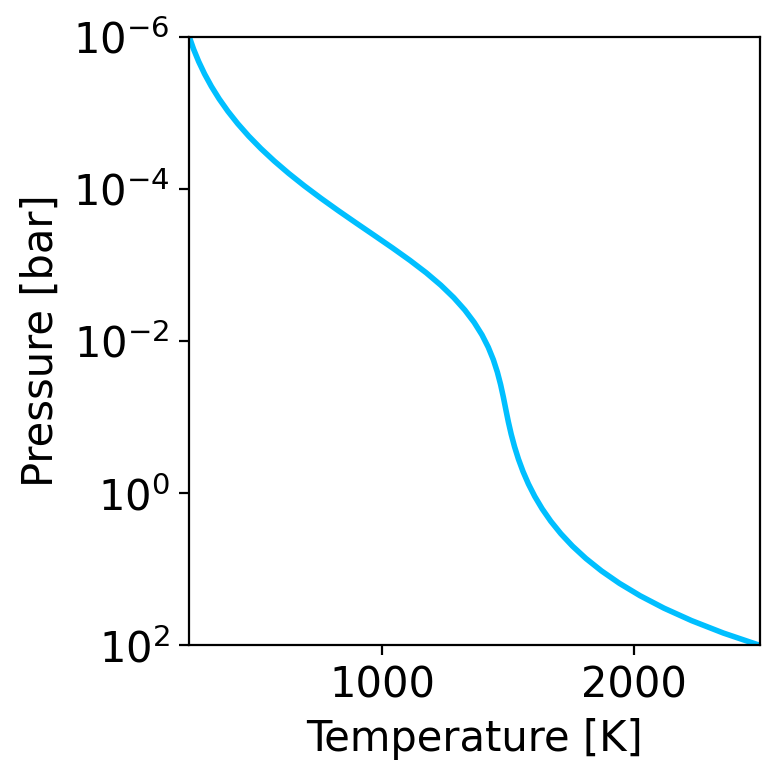

In [ ]:
import matplotlib.pyplot as plt

def plot_simple_pt(retrieval_object,fs=12,**kwargs):

    fig,ax=plt.subplots(1,1,figsize=(4,4),dpi=200)

    # plot PT-profile + errors on retrieved temperatures
    def plot_temperature(retr_obj,ax): 
        if retr_obj.PT_type=='PTgrad':
            dlnT_dlnP_knots=[]
            derr=[]
            for i in range(5):
                key=f'dlnT_dlnP_{i}'
                dlnT_dlnP_knots.append(retr_obj.params_dict[key]) # gradient median values
                derr.append(retr_obj.params_dict[f'{key}_err']) # -/+ errors
            derr=np.array(derr) # gradient errors
            T0=retr_obj.params_dict['T0']
            temperature=retr_obj.model_object.make_pt(dlnT_dlnP_knots=dlnT_dlnP_knots,T_base=T0)
            ax.plot(temperature,retr_obj.model_object.pressure,color=retr_obj.color1,lw=2) 
            xmin,xmax=np.min(temperature),np.max(temperature)
        return xmin,xmax

    xmin,xmax=plot_temperature(retrieval_object,ax)
    ax.set(xlabel='Temperature [K]', ylabel='Pressure [bar]',yscale='log',
        ylim=(np.nanmax(retrieval_object.model_object.pressure),
        np.nanmin(retrieval_object.model_object.pressure)),xlim=(xmin,xmax))
    ax.tick_params(labelsize=fs)
    ax.set_xlabel('Temperature [K]', fontsize=fs)
    ax.set_ylabel('Pressure [bar]', fontsize=fs)

    fig.tight_layout()
    fig.savefig('PT_simple.jpg')

plot_simple_pt(retrieval,fs=15)

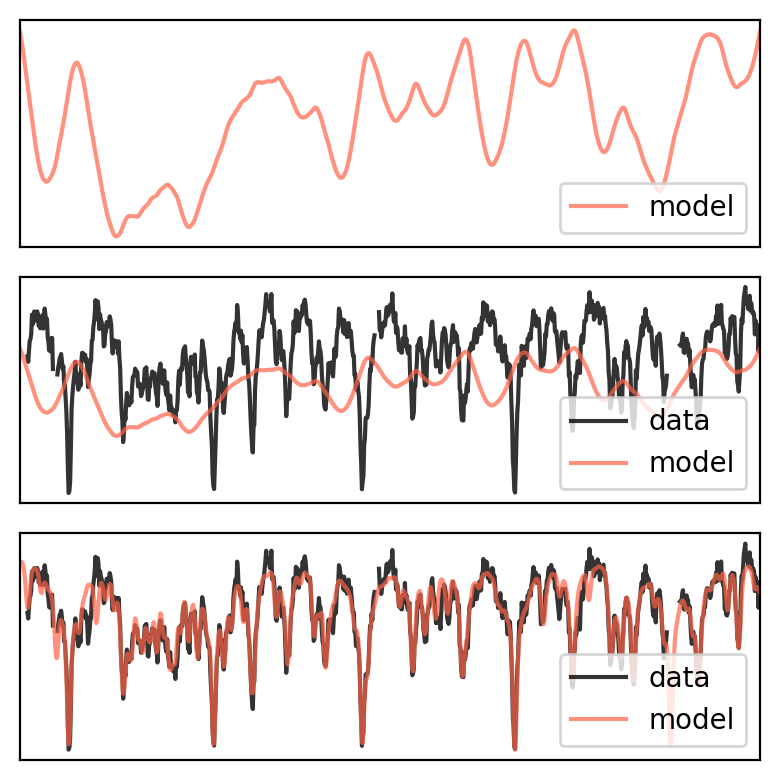

In [ ]:
def load_spectrum(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=np.reshape(file[:,0],(7,3,2048))
    fl=np.reshape(file[:,1],(7,3,2048))
    return wl,fl

def plot_spectrum(wl,fl,flm,flm2,fs=10,**kwargs):

    order=5
    det=0
    n1,n2=0,1000
    wave=wl[order,det][n1:n2]
    flux=fl[order,det][n1:n2]
    flux_m=flm[order,det][n1:n2]
    flux_m2=flm2[order,det][n1:n2]
    #random=np.random.normal(np.zeros_like(flux_m),0.05,size=flux_m.shape)

    fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(5,3),dpi=200)
    ax1.plot(wave,flux_m2,alpha=0.7,c='tomato',label='model')
    ax2.plot(wave,flux,alpha=0.8,c='k',label='data')
    ax2.plot(wave,flux_m2,alpha=0.7,c='tomato',label='model') # show a bad fit
    ax3.plot(wave,flux,alpha=0.8,c='k',label='data')
    ax3.plot(wave,flux_m,alpha=0.7,c='tomato',label='model')

    for ax in (ax1,ax2,ax3): 
        
        ax.legend(loc='lower right')
        #ax.set_ylabel('Flux',fontsize=fs)
        #ax.set_xlabel('Wavelength [nm]',fontsize=fs)
        ax.set_xlim(np.min(wave),np.max(wave))
        ax.tick_params(labelsize=fs)
        ax.set_yticks([])
        ax.set_xticks([])
    fig.tight_layout()
    fig.savefig('fitting_spectra.png',bbox_inches='tight')

wlm,flm=load_spectrum('/home/natalie/Desktop/atm_retrieval/2M0355/freechem_PTgrad_N400_ev0.5/final_spectrum.txt')
wlm,flm2=load_spectrum('/home/natalie/Desktop/atm_retrieval/2M1425/freechem_PTgrad_N300_ev0.5/final_spectrum.txt')
wl,fl=load_spectrum('/home/natalie/Desktop/atm_retrieval/2M0355/2M0355_spectrum.txt')
plot_spectrum(wl,fl,flm,flm2)

# Spectral resolution

0.030353946720319 0.029730443854704046 0.03384314029858458
Mean sigma = 0.03130917695786921
2.3548200450309493
FWHM= 0.07372747749381153
[[26150.53359556 26339.47651471 26519.01597169]
 [27085.03860531 27280.69708562 27466.51038564]
 [28088.4049684  28291.17259745 28483.79438858]
 [29168.79742771 29379.05599581 29579.06342961]
 [30335.15599221 30553.66671959 30761.46837739]
 [31598.1259314  31825.47292174 32041.82563316]
 [32970.2355321  33207.1152376  33432.70473232]]


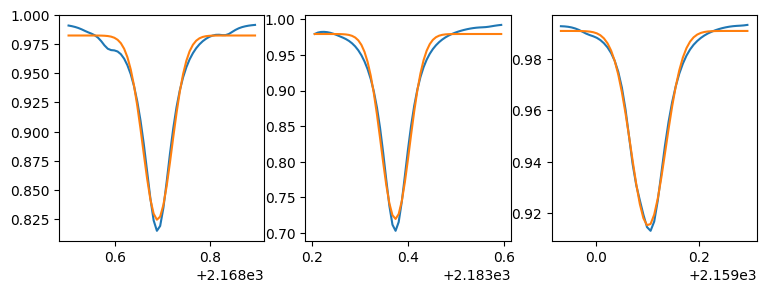

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit 
from target import Target

# Define the Gaussian function 
def Gauss(x, a, x0, sigma, y): 
    return -a*np.exp(-(x-x0)**2/(2*sigma**2))+y

trg = Target('2M0355')
molecfit=f'{trg.name}/SCIENCE_{trg.fullname}_PRIMARY_molecfit_transm.dat'
def load_spec_file(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=file[:,0]
    fl=file[:,1]
    flerr=file[:,2]
    return wl,fl,flerr
wl,fl,_=load_spec_file(molecfit)

# choose 3 clean lines from tellurics and fit Gaussian to them to get FWHM to convert to resolution
fig,ax=plt.subplots(1,3,figsize=(9,3),dpi=100)

l1 = (wl>2168.5)&(wl<2168.9)
wl1 = wl[l1]
fl1 = fl[l1]
res1, _ = curve_fit(Gauss, wl1, fl1, p0=[0.2, np.mean(wl1),0.03,1]) 
#plt.plot(wl1,Gauss(wl1,0.2, np.mean(wl1),0.03,1)) # initial guess
ax[0].plot(wl1,fl1)
y1 = Gauss(wl1,res1[0],res1[1],res1[2],res1[3])
ax[0].plot(wl1,y1)

l2 = (wl>2183.2)&(wl<2183.6)
wl2 = wl[l2]
fl2 = fl[l2]
ax[1].plot(wl2,fl2)
res2, _ = curve_fit(Gauss, wl2, fl2, p0=[0.2, np.mean(wl2),0.03,1]) 
y2 = Gauss(wl2,res2[0],res2[1],res2[2],res2[3])
ax[1].plot(wl2,y2)

l3 = (wl>2158)&(wl<2159.3)
wl3 = wl[l3]
fl3 = fl[l3]
ax[2].plot(wl3,fl3)
res3, _ = curve_fit(Gauss, wl3, fl3, p0=[0.2, np.mean(wl3),0.03,1]) 
y3 = Gauss(wl3,res3[0],res3[1],res3[2],res3[3])
ax[2].plot(wl3,y3)

sigma_mean= np.mean([res1[2],res2[2],res3[2]])
print(res1[2],res2[2],res3[2])
print('Mean sigma =',sigma_mean)

from astropy.stats import gaussian_sigma_to_fwhm
fwhm = sigma_mean*gaussian_sigma_to_fwhm
print(gaussian_sigma_to_fwhm)
print('FWHM=',fwhm)

w,f,_ = trg.load_spectrum()
spec_resolution=np.zeros((7,3))
for order in range(7):
    for det in range(3):
        wave = w[order,det]
        spec_resolution[order,det] = np.median(wave)/(fwhm)

print(spec_resolution)   


# Isotope opacities

In [ ]:
import pandas as pd
from petitRADTRANS import Radtrans
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
species_info = pd.read_csv(os.path.join('species_info.csv'),index_col=0)

Kband=np.array([[[1921.318,1934.583], [1935.543,1948.213], [1949.097,1961.128]],
                [[1989.978,2003.709], [2004.701,2017.816], [2018.708,2031.165]],
                [[2063.711,2077.942], [2078.967,2092.559], [2093.479,2106.392]],
                [[2143.087,2157.855], [2158.914,2173.020], [2173.983,2187.386]],
                [[2228.786,2244.133], [2245.229,2259.888], [2260.904,2274.835]],
                [[2321.596,2337.568], [2338.704,2353.961], [2355.035,2369.534]],
                [[2422.415,2439.061], [2440.243,2456.145], [2457.275,2472.388]]])

def compare_isotopologs(show_species,temp=1500):

    order=5
    det=2
    if show_species=='CO':
        only_params =  ['12CO','13CO']
    elif show_species=='H2O':
        only_params =  ['H2O','H2(18)O']

    colors=[]
    labels=[]
    pRT_names=[]
    for i,par in enumerate(only_params):
        pRT_names.append(species_info.loc[par,'pRT_name'])
        labels.append(species_info.loc[par,'mathtext_name'])
        colors.append(species_info.loc[only_params[i],'color'])

    wlen_range=np.array([np.min(Kband[order,det]),np.max(Kband[order,det])])*1e-3 # nm to microns
    atmosphere = Radtrans(line_species=pRT_names,
                        rayleigh_species = ['H2', 'He'],
                        continuum_opacities = ['H2-H2', 'H2-He'],
                        wlen_bords_micron=wlen_range, 
                        mode='lbl',
                        lbl_opacity_sampling=10)
    
    # use temperature at maximum contribution
    wave_cm, opas = atmosphere.get_opa(np.array([temp]).reshape(1))
    wave_nm = wave_cm*1e7

    fig,ax=plt.subplots(1,1,figsize=(6,3),dpi=200)
    lines=[]
    line_props=[]
    minmax=[]
    for i,m in enumerate(pRT_names):
        spec,=ax.plot(wave_nm,opas[m],lw=0.5,c=colors[i])
        lines.append(Line2D([0],[0],color=spec.get_color(),
                        linewidth=2,label=labels[i]))
        line_props.append((spec.get_color(),labels[i]))
        minmax.append([np.min(opas[m]),np.max(opas[m])])
        
    ymin, ymax= np.min(minmax), np.max(minmax)
    ax.set_yscale('log')
    ax.set_ylabel('Opacity [cm$^2$/g]')
    ax.set_xlabel("Wavelength [nm]")
    ax.set_xlim(np.min(Kband[order,det]),np.max(Kband[order,det]))
    ax.set_ylim(ymin,ymax)

    legend=ax.legend(handles=lines,ncol=3,loc='upper center')
    legend.get_frame().set_alpha(None)
    legend.get_frame().set_facecolor((0, 0, 0, 0))
    legend.get_frame().set_edgecolor((0, 0, 0, 0))
    fig.savefig(f'./figures/{show_species}_iso.pdf',bbox_inches="tight",dpi=200)
    fig.savefig(f'./figures/{show_species}_iso.png',bbox_inches="tight",dpi=200)
    plt.close()

compare_isotopologs('CO')
compare_isotopologs('H2O')